# TCO: retornable vs desechable

Flota multi-planta · 18 meses · 14 plantas · datos MB51 sintéticos

Cuánto cuesta realmente operar con retornables frente a reemplazarlos
con desechables equivalentes, considerando amortización, mantenimiento
y pérdidas por merma.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import polars as pl

DB_PATH = Path("../data/rpi.duckdb")
con = duckdb.connect(str(DB_PATH), read_only=True)

In [2]:
tco = con.execute("""
    SELECT
        tipo_material,
        COUNT(*)                                    AS plantas,
        SUM(ciclos_totales_observados)              AS ciclos_totales,
        MAX(costo_unitario_usd)                     AS costo_unitario_usd,
        MAX(vida_util_ciclos)                       AS vida_util_ciclos,
        MAX(ciclos_payback)                         AS ciclos_payback,
        ROUND(SUM(ahorro_total_vs_desechable_usd), 0) AS ahorro_total_usd,
        ROUND(SUM(perdida_acum_usd), 0)             AS perdida_acum_usd,
        ROUND(SUM(ahorro_neto_usd), 0)              AS ahorro_neto_usd
    FROM mart_tco_comparativo
    GROUP BY tipo_material
    ORDER BY ahorro_neto_usd DESC NULLS LAST
""").pl()

print(tco)

shape: (3, 9)
┌───────────────┬─────────┬────────────────┬────────────────────┬───┬────────────────┬──────────────────┬──────────────────┬─────────────────┐
│ tipo_material ┆ plantas ┆ ciclos_totales ┆ costo_unitario_usd ┆ … ┆ ciclos_payback ┆ ahorro_total_usd ┆ perdida_acum_usd ┆ ahorro_neto_usd │
│ ---           ┆ ---     ┆ ---            ┆ ---                ┆   ┆ ---            ┆ ---              ┆ ---              ┆ ---             │
│ str           ┆ i64     ┆ decimal[38,0]  ┆ decimal[4,1]       ┆   ┆ f64            ┆ f64              ┆ f64              ┆ f64             │
╞═══════════════╪═════════╪════════════════╪════════════════════╪═══╪════════════════╪══════════════════╪══════════════════╪═════════════════╡
│ RACK          ┆ 14      ┆ 923918         ┆ 180.0              ┆ … ┆ 5.0            ┆ 3.71877e7        ┆ 3.63546e6        ┆ 3.355224e7      │
│ KLT           ┆ 14      ┆ 2085975        ┆ 25.0               ┆ … ┆ 6.0            ┆ 8.62196e6        ┆ 1.12955e6        ┆ 7.4

## 1. Headline

Ahorro neto total de operar con retornables frente a reemplazar
con desechables equivalentes en los 18 meses del dataset.

In [3]:
ahorro_klt  = tco.filter(pl.col("tipo_material") == "KLT")["ahorro_neto_usd"][0]
ahorro_rack = tco.filter(pl.col("tipo_material") == "RACK")["ahorro_neto_usd"][0]
perdida_carton = tco.filter(pl.col("tipo_material") == "CARTON")["perdida_acum_usd"][0]

ahorro_total = ahorro_klt + ahorro_rack

print(f"Ahorro neto KLT:        ${ahorro_klt:>15,.0f}")
print(f"Ahorro neto Rack:       ${ahorro_rack:>15,.0f}")
print("─────────────────────────────────────")
print(f"Ahorro neto total:      ${ahorro_total:>15,.0f}")
print()
print(f"Pérdida por merma cartón: ${perdida_carton:>13,.0f}  ← línea base desechable")

Ahorro neto KLT:        $      7,492,410
Ahorro neto Rack:       $     33,552,240
─────────────────────────────────────
Ahorro neto total:      $     41,044,650

Pérdida por merma cartón: $       57,064  ← línea base desechable


## 2. Ahorro neto por tipo de contenedor

KLT y Rack son los únicos tipos con comparativa vs desechable.
Cartón es la línea base — no tiene ahorro porque ES el desechable de referencia,
solo tiene pérdidas por merma.

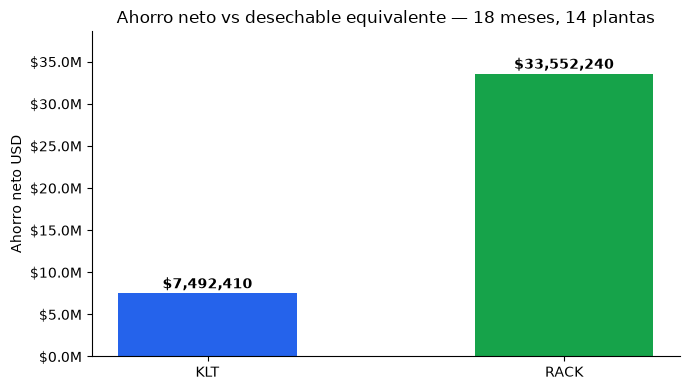

In [4]:
tipos    = ["KLT", "RACK"]
ahorros  = [float(ahorro_klt), float(ahorro_rack)]
colores  = ["#2563eb", "#16a34a"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(tipos, ahorros, color=colores, width=0.5)

for bar, val in zip(bars, ahorros, strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200_000,
        f"${val:,.0f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.set_ylabel("Ahorro neto USD")
ax.set_title("Ahorro neto vs desechable equivalente — 18 meses, 14 plantas")
ax.set_ylim(0, max(ahorros) * 1.15)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../docs/img/tco_ahorro_neto.png", dpi=150)
plt.show()

## 3. Punto de equilibrio

Cuántos ciclos 601→602 necesita cada contenedor para recuperar
su costo de adquisición frente al desechable equivalente.

In [5]:
payback_data = con.execute("""
    SELECT
        tipo_material,
        MAX(costo_unitario_usd)     AS costo_usd,
        MAX(vida_util_ciclos)       AS vida_util,
        MAX(ciclos_payback)         AS payback
    FROM mart_tco_comparativo
    WHERE tipo_material IN ('KLT', 'RACK')
    GROUP BY tipo_material
    ORDER BY tipo_material
""").pl()

for row in payback_data.iter_rows(named=True):
    margen = row["vida_util"] - row["payback"]
    print(
        f"{row['tipo_material']:6s}  "
        f"costo ${row['costo_usd']:>6.0f}  "
        f"payback {row['payback']:>3.0f} ciclos  "
        f"vida útil {row['vida_util']:>3d} ciclos  "
        f"→ {margen:.0f} ciclos de margen"
    )

KLT     costo $    25  payback   6 ciclos  vida útil 150 ciclos  → 144 ciclos de margen
RACK    costo $   180  payback   5 ciclos  vida útil  80 ciclos  → 75 ciclos de margen


## 4. Costo de la merma

La tasa de no-retorno del 2% erosiona parte del ahorro.
Cuánto se pierde por tipo y qué porcentaje representa del ahorro bruto.

In [6]:
merma_data = con.execute("""
    SELECT
        tipo_material,
        ROUND(SUM(ahorro_total_vs_desechable_usd), 0) AS ahorro_bruto_usd,
        ROUND(SUM(perdida_acum_usd), 0)               AS perdida_merma_usd,
        ROUND(SUM(ahorro_neto_usd), 0)                AS ahorro_neto_usd
    FROM mart_tco_comparativo
    WHERE tipo_material IN ('KLT', 'RACK')
    GROUP BY tipo_material
    ORDER BY tipo_material
""").pl()

print(
    f"{'Tipo':<8} {'Ahorro bruto':>14} {'Pérdida merma':>14}"
    f" {'Ahorro neto':>14} {'Merma/Bruto':>12}"
)
print("─" * 66)
for row in merma_data.iter_rows(named=True):
    pct = row["perdida_merma_usd"] / row["ahorro_bruto_usd"] * 100
    print(
        f"{row['tipo_material']:<8} "
        f"${row['ahorro_bruto_usd']:>13,.0f} "
        f"${row['perdida_merma_usd']:>13,.0f} "
        f"${row['ahorro_neto_usd']:>13,.0f} "
        f"{pct:>11.1f}%"
    )

Tipo       Ahorro bruto  Pérdida merma    Ahorro neto  Merma/Bruto
──────────────────────────────────────────────────────────────────
KLT      $    8,621,960 $    1,129,550 $    7,492,410        13.1%
RACK     $   37,187,700 $    3,635,460 $   33,552,240         9.8%


## 5. Sensibilidad a la tasa de merma

Qué pasa con el ahorro neto si la merma sube de 2% a 5% o baja a 1%.
La pérdida se escala en proporción a la tasa, partiendo de la merma real
observada al 2%, así que el escenario de 2% cuadra con el headline.
El costo unitario de KLT es \$25 y el de Rack \$180: cada punto de merma
pega muy distinto entre tipos.

 Merma        KLT neto       Rack neto      Total neto
────────────────────────────────────────────────────────
   1%  $    8,057,185  $   35,369,970  $   43,427,155
   2%  $    7,492,410  $   33,552,240  $   41,044,650
   3%  $    6,927,635  $   31,734,510  $   38,662,145
   4%  $    6,362,860  $   29,916,780  $   36,279,640
   5%  $    5,798,085  $   28,099,050  $   33,897,135

Cada punto de merma: $2,382,505 en 18 meses, $1,588,337 por año


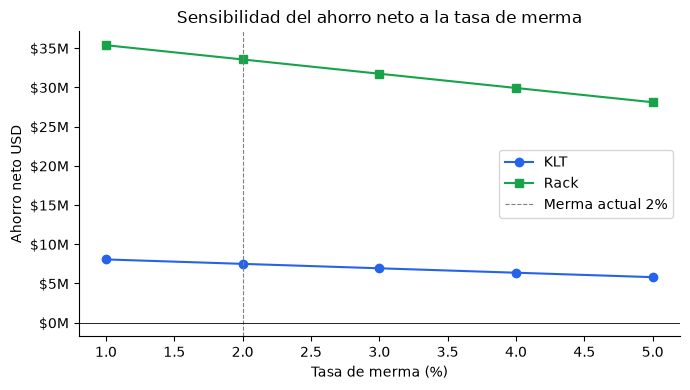

In [7]:
escenarios = [0.01, 0.02, 0.03, 0.04, 0.05]
tasa_base = 0.02


def valor(tipo, columna):
    return float(tco.filter(pl.col("tipo_material") == tipo)[columna][0])


ahorro_bruto_klt = valor("KLT", "ahorro_total_usd")
ahorro_bruto_rack = valor("RACK", "ahorro_total_usd")
merma_base_klt = valor("KLT", "perdida_acum_usd")
merma_base_rack = valor("RACK", "perdida_acum_usd")

print(f"{'Merma':>6}  {'KLT neto':>14}  {'Rack neto':>14}  {'Total neto':>14}")
print("─" * 56)

netos_klt  = []
netos_rack = []

for tasa in escenarios:
    perdida_klt  = merma_base_klt  * tasa / tasa_base
    perdida_rack = merma_base_rack * tasa / tasa_base
    neto_klt     = ahorro_bruto_klt  - perdida_klt
    neto_rack    = ahorro_bruto_rack - perdida_rack
    netos_klt.append(neto_klt)
    netos_rack.append(neto_rack)
    print(
        f"{tasa:>5.0%}  "
        f"${neto_klt:>13,.0f}  "
        f"${neto_rack:>13,.0f}  "
        f"${neto_klt + neto_rack:>13,.0f}"
    )

costo_por_punto = (merma_base_klt + merma_base_rack) / (tasa_base * 100)
print()
print(
    f"Cada punto de merma: ${costo_por_punto:,.0f} en 18 meses, "
    f"${costo_por_punto / 1.5:,.0f} por año"
)

# gráfico
fig, ax = plt.subplots(figsize=(7, 4))
pcts = [t * 100 for t in escenarios]
ax.plot(pcts, [v / 1e6 for v in netos_klt],  marker="o", label="KLT",  color="#2563eb")
ax.plot(pcts, [v / 1e6 for v in netos_rack], marker="s", label="Rack", color="#16a34a")
ax.axvline(x=2, color="gray", linestyle="--", linewidth=0.8, label="Merma actual 2%")
ax.axhline(y=0, color="black", linewidth=0.6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.set_xlabel("Tasa de merma (%)")
ax.set_ylabel("Ahorro neto USD")
ax.set_title("Sensibilidad del ahorro neto a la tasa de merma")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../docs/img/tco_sensibilidad.png", dpi=150)
plt.show()

## 6. Resumen ejecutivo

- Operar con KLTs plásticos y racks metálicos genera un ahorro neto de
  **\$41.0M USD** frente a reemplazarlos con desechables equivalentes
  en 18 meses sobre 14 plantas.

- El rack metálico recupera su inversión en **5 ciclos** y le quedan 75 ciclos
  de vida útil. El KLT recupera en **6 ciclos** con 144 ciclos de margen.

- La merma del 2% se come el 13.1% del ahorro bruto en KLT y el 9.8% en Rack.
  Cada punto porcentual de merma cuesta ~\$2.4M en 18 meses (~\$1.6M por año)
  sobre esta flota.

- Bajar la tasa de no-retorno de 2% a 1% recupera esos ~\$1.6M por año sin
  comprar un solo contenedor más.

In [8]:
con.close()